# Chapter 38 Lab — Machine Learning Principles and Algorithms (Python)

This lab makes the core principles of machine learning concrete with small simulations: the U-shaped test error curve and the bias–variance tradeoff, ridge vs. lasso regularization paths, cross-validation done wrong vs. right (feature-selection leakage), and ROC curves for evaluating classifiers.

**How to run this notebook.** You can run it directly in your browser (each cell takes a few seconds), open it in Colab with the badge on the chapter page, or download and run it locally. Everything uses numpy, scikit-learn, and matplotlib on simulated data — no fMRI files needed. If anything is unfamiliar, revisit the [chapter page](../ch38-machine-learning-principles-and-algorithms.md) first.

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
plt.rcParams["figure.dpi"] = 100

## 1. Overfitting and the U-shaped test error curve

Machine learning judges models by how well they predict **new** data. To see why that matters, we simulate observations from a smooth true function, $y = \sin(2x) + \varepsilon$, and fit polynomials of increasing degree — a simple dial for model complexity. We fit on a small training set and evaluate on an independent test set.

- **Training error** can only go down as complexity grows: a more flexible model always fits the points it was trained on more closely.
- **Test error** is U-shaped: it falls while flexibility captures real structure (reducing *bias*), then rises as the model starts fitting noise (increasing *variance*).

Best test-set degree: 7  (true function is smooth and sine-like)


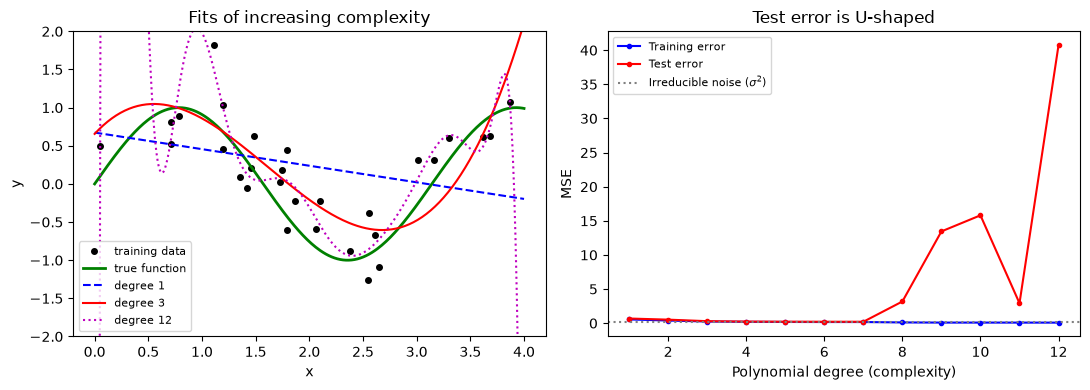

In [2]:
f_true = lambda x: np.sin(2 * x)
sigma = 0.4                                   # noise SD

n_train, n_test = 30, 400
x_train = 4 * rng.random(n_train)
y_train = f_true(x_train) + sigma * rng.standard_normal(n_train)
x_test = 4 * rng.random(n_test)
y_test = f_true(x_test) + sigma * rng.standard_normal(n_test)

degrees = np.arange(1, 13)
train_mse, test_mse, fits = [], [], {}
for d in degrees:
    p = np.polyfit(x_train, y_train, d)        # fit uses training data ONLY
    train_mse.append(np.mean((y_train - np.polyval(p, x_train)) ** 2))
    test_mse.append(np.mean((y_test - np.polyval(p, x_test)) ** 2))
    fits[d] = p

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
xx = np.linspace(0, 4, 300)
axes[0].plot(x_train, y_train, "ko", ms=4, label="training data")
axes[0].plot(xx, f_true(xx), "g-", lw=2, label="true function")
for d, style in [(1, "b--"), (3, "r-"), (12, "m:")]:
    axes[0].plot(xx, np.polyval(fits[d], xx), style, label=f"degree {d}")
axes[0].set(ylim=(-2, 2), xlabel="x", ylabel="y", title="Fits of increasing complexity")
axes[0].legend(fontsize=8)

axes[1].plot(degrees, train_mse, "b.-", label="Training error")
axes[1].plot(degrees, test_mse, "r.-", label="Test error")
axes[1].axhline(sigma**2, color="gray", ls=":", label="Irreducible noise ($\sigma^2$)")
axes[1].set(xlabel="Polynomial degree (complexity)", ylabel="MSE",
            title="Test error is U-shaped")
axes[1].legend(fontsize=8)
plt.tight_layout()

best = degrees[int(np.argmin(test_mse))]
print(f"Best test-set degree: {best}  (true function is smooth and sine-like)")

The degree-1 fit *underfits* (high bias: systematically wrong everywhere), while the degree-12 fit *overfits* (high variance: it chases individual noisy points). The best test error lands at moderate complexity — and no model beats the irreducible noise floor $\sigma^2$.

## 2. The bias–variance tradeoff, visualized

Bias and variance are statements about what happens **across repeated samples**. We redraw the training set many times, refit each model, and overlay the fitted curves. A simple model gives nearly the same (wrong) curve every time — high bias, low variance. A complex model gives wildly different curves each time — low bias, high variance.

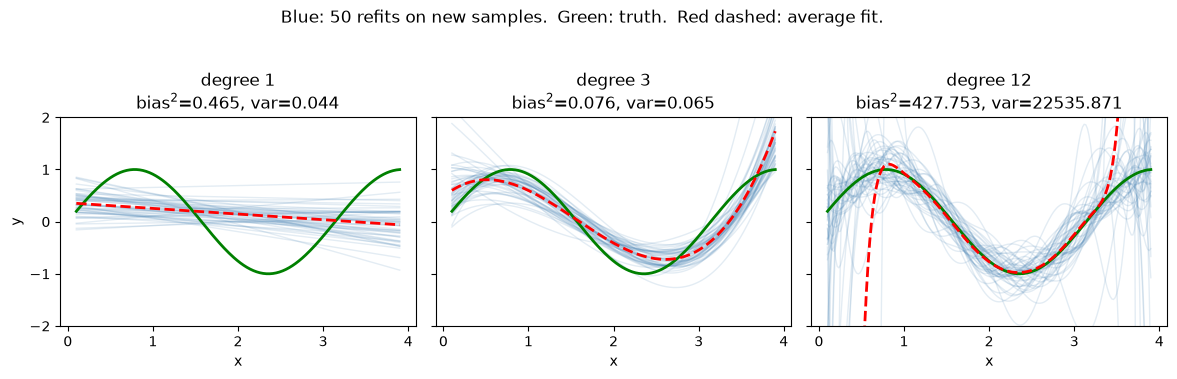

In [3]:
n_sims = 50
xx = np.linspace(0.1, 3.9, 200)
show_degrees = [1, 3, 12]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, d in zip(axes, show_degrees):
    curves = np.empty((n_sims, xx.size))
    for s in range(n_sims):
        xs = 4 * rng.random(n_train)
        ys = f_true(xs) + sigma * rng.standard_normal(n_train)
        curves[s] = np.polyval(np.polyfit(xs, ys, d), xx)
    ax.plot(xx, curves.T, color="steelblue", alpha=0.15, lw=1)
    ax.plot(xx, f_true(xx), "g-", lw=2)
    ax.plot(xx, curves.mean(0), "r--", lw=2)
    bias2 = np.mean((curves.mean(0) - f_true(xx)) ** 2)
    var = curves.var(0).mean()
    ax.set(ylim=(-2, 2), xlabel="x",
           title=f"degree {d}\nbias$^2$={bias2:.3f}, var={var:.3f}")
axes[0].set_ylabel("y")
fig.suptitle("Blue: 50 refits on new samples.  Green: truth.  Red dashed: average fit.", y=1.04)
plt.tight_layout()

The printed decomposition mirrors the picture: degree 1 has large bias² and tiny variance; degree 12 has near-zero bias² and large variance; degree 3 balances the two. Expected test error ≈ bias² + variance + $\sigma^2$, which is exactly why the test error curve in Section 1 is U-shaped.

## 3. Regularization: ridge and lasso coefficient paths

When features are many and correlated — the norm in fMRI — regularization controls complexity *continuously* instead of by discrete model choice. We minimize a penalized loss $\mathcal{L}(w) = E(w) + \lambda R(w)$ with

- **L2 / ridge**: $R(w) = \sum_j w_j^2$ — shrinks all coefficients smoothly toward zero,
- **L1 / lasso**: $R(w) = \sum_j |w_j|$ — drives the least useful coefficients *exactly* to zero (sparsity).

We simulate 40 correlated features of which only 5 truly matter, then trace every coefficient as the regularization strength $\lambda$ (called `alpha` in scikit-learn) varies.

Lasso nonzero coefficients along the path (high to low lambda):
[ 0  1  3  5  6  7 10 11 13 19 23 25 28 30 31 32 33 36 37 38 39 40]


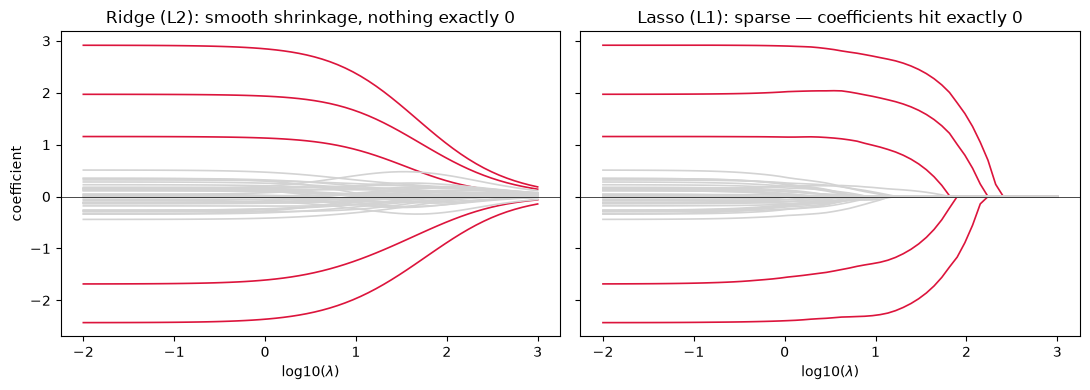

In [4]:
from sklearn.linear_model import Ridge, lasso_path

n, p, p_true = 80, 40, 5
# correlated design: features share a common latent factor
latent = rng.standard_normal((n, 1))
X = 0.6 * latent + rng.standard_normal((n, p))
X = (X - X.mean(0)) / X.std(0)
w_true = np.zeros(p); w_true[:p_true] = [3, -2.5, 2, -1.5, 1]
y = X @ w_true + rng.standard_normal(n)

alphas = np.logspace(-2, 3, 60)

# Ridge path: refit at each alpha
ridge_coefs = np.array([Ridge(alpha=a).fit(X, y).coef_ for a in alphas])

# Lasso path (efficient built-in path algorithm)
alphas_lasso, lasso_coefs, _ = lasso_path(X, y, alphas=alphas / n)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for j in range(p):
    c = "crimson" if w_true[j] != 0 else "lightgray"
    axes[0].plot(np.log10(alphas), ridge_coefs[:, j], color=c, lw=1.2)
    axes[1].plot(np.log10(alphas_lasso * n), lasso_coefs[j], color=c, lw=1.2)
axes[0].set(title="Ridge (L2): smooth shrinkage, nothing exactly 0",
            xlabel="log10($\lambda$)", ylabel="coefficient")
axes[1].set(title="Lasso (L1): sparse — coefficients hit exactly 0",
            xlabel="log10($\lambda$)")
for ax in axes: ax.axhline(0, color="k", lw=0.5)
plt.tight_layout()

n_nonzero = (np.abs(lasso_coefs) > 1e-8).sum(0)
print("Lasso nonzero coefficients along the path (high to low lambda):")
print(np.array(sorted(set(n_nonzero))))

Red paths are the 5 truly predictive features; gray paths are pure noise. Ridge shrinks everything smoothly but keeps all 40 features; lasso zeroes out the noise features over a wide range of $\lambda$, recovering a sparse model. With strongly correlated features, though, lasso picks one arbitrary representative per correlated set — in whole-brain models this produces scattered "speckles," motivating elastic net, structured penalties (GraphNet), and LASSO-PCR on component scores.

In practice $\lambda$ is a **hyperparameter** chosen by cross-validation — which brings us to the most important cautionary tale in this lab.

## 4. Cross-validation done WRONG vs. right

Cross-validation is only valid if **every data-dependent choice** — feature selection, scaling parameters, hyperparameter tuning — is made using training folds only. A classic mistake is to select the features most correlated with the outcome using the *whole* dataset, and only then cross-validate. The selection step has already peeked at the test folds.

To show how bad this is, we use features that are **pure noise**: true generalization accuracy is exactly 50%. Any excess is *optimism* created by leakage.

WRONG (select on all data, then CV): 91.2% (range 80%-100%)
RIGHT (select inside each fold):     54.1% (range 38%-74%)
True accuracy of any model here:     50.0% (features are pure noise)
Average optimism from leakage:       +37.1%


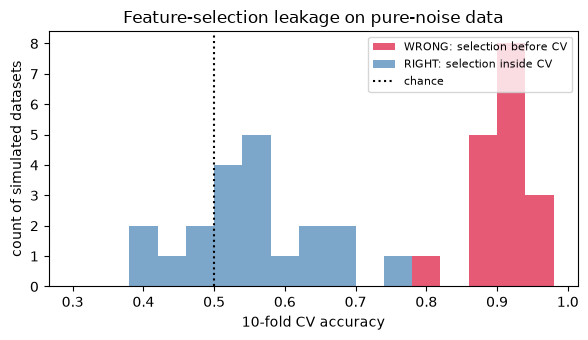

In [5]:
from sklearn.model_selection import StratifiedKFold

n, p, k_feats = 50, 2000, 20

def top_k_features(Xa, ya, k):
    """Indices of the k features most correlated (|r|) with the outcome."""
    Xc = Xa - Xa.mean(0)
    r = (Xc.T @ (ya - ya.mean())) / (np.sqrt((Xc**2).sum(0)) *
                                     np.sqrt(((ya - ya.mean())**2).sum()) + 1e-12)
    return np.argsort(np.abs(r))[-k:]

def fit_predict(Xtr, ytr, Xte):
    """Least-squares linear classifier: sign(X w)."""
    w = np.linalg.lstsq(Xtr, ytr, rcond=None)[0]
    return np.sign(Xte @ w)

def cv_accuracy(X, y, select_first, seed=0):
    sel_all = top_k_features(X, y, k_feats) if select_first else None
    skf = StratifiedKFold(10, shuffle=True, random_state=seed)
    correct = 0
    for tr, te in skf.split(X, y):
        sel = sel_all if select_first else top_k_features(X[tr], y[tr], k_feats)
        correct += np.sum(fit_predict(X[tr][:, sel], y[tr], X[te][:, sel]) == y[te])
    return correct / len(y)

n_datasets = 20
acc_wrong, acc_right = [], []
for s in range(n_datasets):
    Xs = rng.standard_normal((n, p))            # PURE NOISE features
    ys = np.repeat([1.0, -1.0], n // 2)
    acc_wrong.append(cv_accuracy(Xs, ys, select_first=True, seed=s))
    acc_right.append(cv_accuracy(Xs, ys, select_first=False, seed=s))
acc_wrong, acc_right = np.array(acc_wrong), np.array(acc_right)

print(f"WRONG (select on all data, then CV): {acc_wrong.mean():.1%} "
      f"(range {acc_wrong.min():.0%}-{acc_wrong.max():.0%})")
print(f"RIGHT (select inside each fold):     {acc_right.mean():.1%} "
      f"(range {acc_right.min():.0%}-{acc_right.max():.0%})")
print(f"True accuracy of any model here:     50.0% (features are pure noise)")
print(f"Average optimism from leakage:       {(acc_wrong - acc_right).mean():+.1%}")

plt.figure(figsize=(6, 3.5))
plt.hist(acc_wrong, bins=np.arange(0.3, 1.01, 0.04), alpha=0.7,
         label="WRONG: selection before CV", color="crimson")
plt.hist(acc_right, bins=np.arange(0.3, 1.01, 0.04), alpha=0.7,
         label="RIGHT: selection inside CV", color="steelblue")
plt.axvline(0.5, color="k", ls=":", label="chance")
plt.xlabel("10-fold CV accuracy"); plt.ylabel("count of simulated datasets")
plt.title("Feature-selection leakage on pure-noise data")
plt.legend(fontsize=8); plt.tight_layout()

On data with **no signal whatsoever**, the leaky pipeline reports accuracies far above chance — often 75–90% — while the correct pipeline hovers around 50%. The gap is the optimism bought by letting the test folds influence feature selection. With real data the same bias operates silently on top of any true signal, inflating published accuracies. The rule: *cross-validation must wrap the entire pipeline*, including selection, scaling, and hyperparameter tuning (nested CV; Chapter 39).

## 5. ROC curves and AUC

Accuracy at a single threshold hides how a classifier trades off sensitivity against specificity. The **ROC curve** sweeps the decision threshold across all values of a continuous score, plotting the true positive rate against the false positive rate. The **area under the curve (AUC)** summarizes separability: 0.5 = uninformative, 1.0 = perfect. We compare an informative model (class means differ by $d' = 1.5$) with an uninformative one ($d' = 0$).

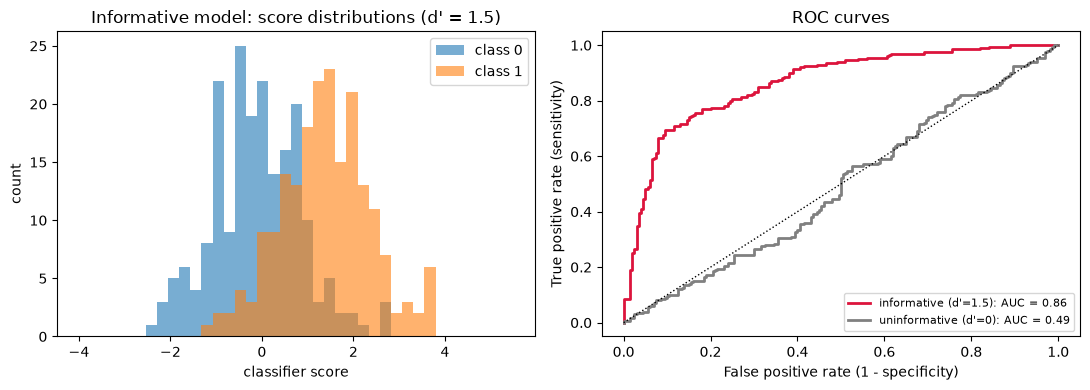

In [6]:
from sklearn.metrics import roc_curve, auc

# Adapted from CANlab simple_ROC_demo (github.com/canlab/ComputationalFoundations)
n_per = 200
labels = np.repeat([0, 1], n_per)

scores_good = np.r_[rng.standard_normal(n_per), 1.5 + rng.standard_normal(n_per)]
scores_null = np.r_[rng.standard_normal(n_per), 0.0 + rng.standard_normal(n_per)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bins = np.linspace(-4, 5.5, 40)
axes[0].hist(scores_good[labels == 0], bins=bins, alpha=0.6, label="class 0")
axes[0].hist(scores_good[labels == 1], bins=bins, alpha=0.6, label="class 1")
axes[0].set(title="Informative model: score distributions (d' = 1.5)",
            xlabel="classifier score", ylabel="count")
axes[0].legend()

for scores, name, color in [(scores_good, "informative (d'=1.5)", "crimson"),
                            (scores_null, "uninformative (d'=0)", "gray")]:
    fpr, tpr, _ = roc_curve(labels, scores)
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name}: AUC = {auc(fpr, tpr):.2f}")
axes[1].plot([0, 1], [0, 1], "k:", lw=1)
axes[1].set(title="ROC curves", xlabel="False positive rate (1 - specificity)",
            ylabel="True positive rate (sensitivity)")
axes[1].legend(fontsize=8); plt.tight_layout()

The uninformative model's ROC hugs the diagonal (AUC ≈ 0.5): at every threshold, sensitivity gains are paid for one-to-one with false positives. The informative model bows toward the top-left corner. AUC is threshold-free and insensitive to class base rates, which makes it a standard headline metric for decoding models — though for clinical translation the operating point (a specific sensitivity/specificity pair) matters as much as the area (Chapter 41).

## Wrap-up

- **Test error is U-shaped in complexity**; training error is a biased, ever-improving illusion. Manage the bias–variance tradeoff, don't ignore it.
- **Regularization** turns complexity into a continuous dial: ridge shrinks smoothly, lasso sparsifies, elastic net blends the two — all deliberately trade a little bias for a big variance reduction.
- **Cross-validation is only as honest as its weakest step**: any choice made with all the data (feature selection, scaling, tuning) leaks and inflates accuracy — dramatically, even on pure noise.
- **ROC/AUC** characterize a classifier across all thresholds, separating discriminability from threshold choice.

Chapter 39 builds on this foundation: cross-validation schemes, nested CV for hyperparameter tuning, and unbiased performance estimation for predictive brain models.